In [7]:
#!pip install pennylane --upgrade

# Change numpy to 2.0.0

In [8]:
#!pip uninstall numpy -y

In [9]:
#!pip install numpy==2.0.0

In [10]:
#!pip install numpy==2.0.0

In [11]:
#!pip install beliefmatching --upgrade

In [12]:
#!pip install numba --upgrade

In [13]:
#!pip install streamlit --upgrade

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from matplotlib.ticker import MaxNLocator


Energy % difference: 6.67e-01   E = -10.000000
Energy % difference: 1.45e-01   E = -11.454545
Energy % difference: 3.54e-02   E = -11.860465
Energy % difference: 8.81e-03   E = -11.964912
Energy % difference: 2.20e-03   E = -11.991215
Energy % difference: 5.49e-04   E = -11.997803
Energy % difference: 1.37e-04   E = -11.999451
Energy % difference: 3.43e-05   E = -11.999863
Energy % difference: 8.58e-06   E = -11.999966
Energy % difference: 2.15e-06   E = -11.999991
Converged. Final energy: -11.999998


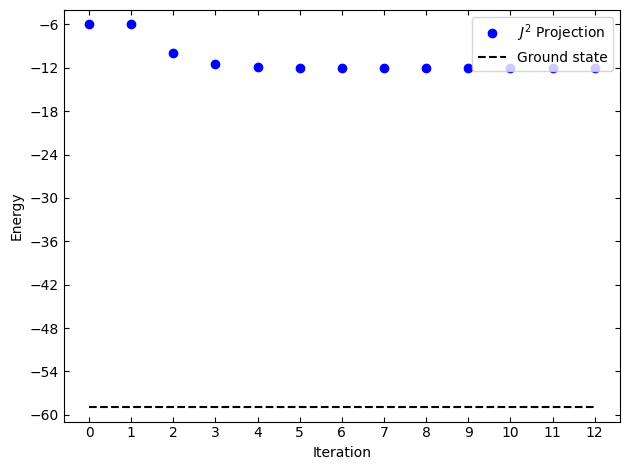

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from matplotlib.ticker import MaxNLocator


NUM_SYSTEM_QUBITS = 4#12          # 4×3 lattice
NUM_AUX = 4                     # ancilla qubits
NUM_TOTAL = NUM_SYSTEM_QUBITS + NUM_AUX

times  = [np.pi / 2, np.pi / 4, np.pi / 8, np.pi / 16]
phases = [0, 0, 0, 0]


pauli_strings_qiskit = [
    'XIIXIIIIIIII', 'YIIYIIIIIIII', 'ZIIZIIIIIIII', 'XXIIIIIIIIII',
    'YYIIIIIIIIII', 'ZZIIIIIIIIII', 'XIIIIIIIXIII', 'YIIIIIIIYIII',
    'ZIIIIIIIZIII', 'XIIIXIIIIIII', 'YIIIYIIIIIII', 'ZIIIZIIIIIII',
    'IIIIXIIXIIII', 'IIIIYIIYIIII', 'IIIIZIIZIIII', 'IIIIXXIIIIII',
    'IIIIYYIIIIII', 'IIIIZZIIIIII', 'IIIIXIIIXIII', 'IIIIYIIIYIII',
    'IIIIZIIIZIII', 'IIIIIIIIXIIX', 'IIIIIIIIYIIY', 'IIIIIIIIZIIZ',
    'IIIIIIIIXXII', 'IIIIIIIIYYII', 'IIIIIIIIZZII', 'IXXIIIIIIIII',
    'IYYIIIIIIIII', 'IZZIIIIIIIII', 'IXIIIIIIIXII', 'IYIIIIIIIYII',
    'IZIIIIIIIZII', 'IXIIIXIIIIII', 'IYIIIYIIIIII', 'IZIIIZIIIIII',
    'IIIIIXXIIIII', 'IIIIIYYIIIII', 'IIIIIZZIIIII', 'IIIIIXIIIXII',
    'IIIIIYIIIYII', 'IIIIIZIIIZII', 'IIIIIIIIIXXI', 'IIIIIIIIIYYI',
    'IIIIIIIIIZZI', 'IIXXIIIIIIII', 'IIYYIIIIIIII', 'IIZZIIIIIIII',
    'IIXIIIIIIIXI', 'IIYIIIIIIIYI', 'IIZIIIIIIIZI', 'IIXIIIXIIIII',
    'IIYIIIYIIIII', 'IIZIIIZIIIII', 'IIIIIIXXIIII', 'IIIIIIYYIIII',
    'IIIIIIZZIIII', 'IIIIIIXIIIXI', 'IIIIIIYIIIYI', 'IIIIIIZIIIZI',
    'IIIIIIIIIIXX', 'IIIIIIIIIIYY', 'IIIIIIIIIIZZ', 'IIIXIIIIIIIX',
    'IIIYIIIIIIIY', 'IIIZIIIIIIIZ', 'IIIXIIIXIIII', 'IIIYIIIYIIII',
    'IIIZIIIZIIII', 'IIIIIIIXIIIX', 'IIIIIIIYIIIY', 'IIIIIIIZIIIZ',
]

pauli_strings_qiskit = ['XXII','YYII','ZZII','IXXI','IYYI','IZZI'
                        ,'IIXX','IIYY','IIZZ']

# reverse Qiskit -> PennyLane 
pauli_strings_pl = [s[::-1] for s in pauli_strings_qiskit]
coeffs = [2.0] * len(pauli_strings_pl)


def make_hamiltonian():
    ops = []
    for pstr in pauli_strings_pl:
        terms = []
        for wire, ch in enumerate(pstr):
            if ch != 'I':
                terms.append(getattr(qml, ch)(wire))
        if len(terms) == 1:
            ops.append(terms[0])
        else:
            prod = terms[0]
            for t in terms[1:]:
                prod = prod @ t
            ops.append(prod)
    return qml.Hamiltonian(coeffs, ops)

H = make_hamiltonian()
H_matrix = qml.matrix(H, wire_order=list(range(NUM_SYSTEM_QUBITS)))


dev_total  = qml.device("default.qubit", wires=NUM_TOTAL)
dev_system = qml.device("default.qubit", wires=NUM_SYSTEM_QUBITS)


AUX_WIRES    = list(range(NUM_AUX))              
SYSTEM_WIRES = list(range(NUM_AUX, NUM_TOTAL))     

SYSTEM_WIRES_LOCAL = list(range(NUM_SYSTEM_QUBITS)) 

# superposition of Neel states
def initialize_state(state1: str, state2: str, wires: list):

    n = len(state1)
    assert n == len(state2) == len(wires)
 
    s1 = state1[::-1]   
    s2 = state2[::-1]
 
    for i, bit in enumerate(s1):
        if bit == '1':
            qml.PauliX(wires=wires[i])
 
    control_qubits = [i for i in range(n) if s1[i] != s2[i]]
    ctrl = control_qubits[0]
    qml.Hadamard(wires=wires[ctrl])
    for i in control_qubits[1:]:
        qml.CNOT(wires=[wires[ctrl], wires[i]])
 
 
def projection_gates(state_vector=None, times=times, phases=phases, apply_rx=False):
    if state_vector is not None:
        qml.StatePrep(state_vector, wires=SYSTEM_WIRES, normalize=True)
    else:
        #initialize_state("101001011010", "010110100101", SYSTEM_WIRES)
        initialize_state("1010", "0101", SYSTEM_WIRES)
 
    if apply_rx:
        for w in SYSTEM_WIRES:
            qml.RX(np.pi / 2, wires=w)
 
    for j, (t, delta) in enumerate(zip(times, phases)):
        aux = AUX_WIRES[j]
 
        qml.adjoint(qml.S)(wires=aux)
        qml.Hadamard(wires=aux)
 
        for sys_w in SYSTEM_WIRES:
            qml.CNOT(wires=[aux, sys_w])
            qml.RZ(2 * t + delta, wires=sys_w)
            qml.CNOT(wires=[aux, sys_w])
 
        qml.Hadamard(wires=aux)
        qml.S(wires=aux)
 
 
@qml.qnode(dev_total)
def get_full_statevector(state_vector=None, apply_rx=False):
    projection_gates(state_vector=state_vector, apply_rx=apply_rx)
    return qml.state()
 
 
def apply_Jz_projection(state_vector=None, apply_rx=False):
    full_sv = np.array(get_full_statevector(state_vector=state_vector,
                                              apply_rx=apply_rx))
 

    dim_sys = 2 ** NUM_SYSTEM_QUBITS   
    dim_aux = 2 ** NUM_AUX             
 
    sv_reshaped = full_sv.reshape(dim_aux, dim_sys)
 
    raw = sv_reshaped[0, :]
 
    norm = np.linalg.norm(raw)
    psi = raw / norm
 
    exp = np.vdot(psi, H_matrix @ psi).real
    return psi, exp
 
 
def apply_first_Jz_projection():

    @qml.qnode(dev_system)
    def initial_sv():
        #initialize_state("101001011010", "010110100101", SYSTEM_WIRES_LOCAL)
        initialize_state("1010", "0101", SYSTEM_WIRES_LOCAL)
        return qml.state()
 
    initial_state = np.array(initial_sv())
    e_0 = np.vdot(initial_state, H_matrix @ initial_state).real
 
    psi, e_p = apply_Jz_projection(state_vector=None, apply_rx=False)
    return psi, e_p, e_0
 
 
def apply_Jx_and_Jz_projection(state_vector):

    return apply_Jz_projection(state_vector=state_vector, apply_rx=True)
 

def driver():
    v0, e_p, e_0 = apply_first_Jz_projection()
    v_c, e_c = apply_Jx_and_Jz_projection(v0)
    exp_vals = [e_0, e_p, e_c]
 
    while (diff := abs((e_c - e_p) / e_p)) > 1e-6:
        print(f"Energy % difference: {diff:.2e}   E = {e_c:.6f}")
        e_p = e_c
        v_c, e_c = apply_Jx_and_Jz_projection(v_c)
        exp_vals.append(e_c)
 
    print(f"Converged. Final energy: {e_c:.6f}")
    return exp_vals, v_c
 
 

def plot(exp_vals):
    actual = -58.94574155307309 
 
    n = len(exp_vals)
    x = list(range(n))
 
    fig, ax = plt.subplots()
    ax.set_ylim(actual - 2, exp_vals[0] + 2)
    ax.set_xticks(x)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(direction="in", top=True, right=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Energy")
    ax.plot(x, exp_vals, "bo", label=r"$J^2$ Projection")
    ax.plot([0, n - 1], [actual, actual], "k--", label="Ground state")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

exp_vals, final_state = driver()
plot(exp_vals)

In [52]:
exp_vals

[-5.999999999999999,
 -6.000000000000001,
 -10.0,
 -11.454545454545453,
 -11.86046511627907,
 -11.964912280701753,
 -11.991215226939968,
 -11.997803002563156,
 -11.99945070035704,
 -11.999862671946165,
 -11.999965667790093,
 -11.999991416935243,
 -11.999997854233039]

In [53]:
def string_to_H(str_op,coefs):
    tot_H=0
    for j,term in enumerate(str_op):
        h=qml.Identity(0)
        for i,p in enumerate(term):
            if p=='X':
                h=h@qml.PauliX(i)
            elif p=='Y':
                h=h@qml.PauliY(i)
            elif p=='Z':
                h=h@qml.PauliZ(i)
            elif p=='Y':
                    h=h@qml.PauliY(i)
        tot_H=tot_H+coefs[j]*h
    return tot_H

In [55]:
coefs=len(pauli_strings_qiskit)*[2.0]
H=string_to_H(pauli_strings_qiskit,coefs)

In [56]:

import pennylane as qml
from pennylane import numpy as np

# Heisenberg Hamiltonian
J = 1.0

#H = (
#    1*J * (qml.PauliX(0) @ qml.PauliX(1))
#    + J * (qml.PauliY(0) @ qml.PauliY(1))
#    + J * (qml.PauliZ(0) @ qml.PauliZ(1))
#)

# Convert to matrix
H_matrix = qml.matrix(H)

print("Hamiltonian Matrix:")
print(H_matrix)

# Diagonalization
eigvals, eigvecs = np.linalg.eigh(H_matrix)

print("\nEigenvalues:")
print(eigvals)

print("\nGround state energy:")
print(eigvals[0])

print("\nGround state vector:")
print(eigvecs[:,0])

Hamiltonian Matrix:
[[ 6.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  2.+0.j  4.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  4.+0.j -2.+0.j  0.+0.j  4.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  2.+0.j  0.+0.j  4.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  4.+0.j  0.+0.j -2.+0.j  0.+0.j  0.+0.j  0.+0.j  4.+0.j
   0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  4.+0.j  0.+0.j -6.+0.j  4.+0.j  0.+0.j  0.+0.j
   4.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  4.+0.j -2.+0.j  0.+0.j  0.+0.j
   0.+0.j  4.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j

In [70]:
state=final_state#eigvecs[:,0]
#import pennylane as qml
#from pennylane import numpy as np

# Number of estimation qubits
n_estimation = 7

# Total wires
wires = list(range(n_estimation + 1))

dev = qml.device("default.qubit", wires=n_estimation + 4)

# Test with Pauli Z Hamiltonian
#H = qml.PauliZ(n_estimation)

# Evolution time
t = np.pi / 2**6

# U = exp(-iHt)
U = qml.matrix(qml.exp(H, coeff=-1j * t))

@qml.qnode(dev)
def qpe():

    # Prepare eigenstate |1>
    #qml.PauliX(wires=n_estimation)
    qml.StatePrep(state, wires=[10,9,8,7])

    # Apply QPE
    qml.QuantumPhaseEstimation(
        U,
        target_wires=[n_estimation+3,n_estimation+2,n_estimation+1,n_estimation],
        estimation_wires=list(range(n_estimation))
    )

    return qml.probs(wires=range(n_estimation))

probs = qpe()

print("Measurement probabilities:")
for i, p in enumerate(probs):
    if p > 1e-4:
        print(f"{i:04b}: {p:.4f}")

phase_index = np.argmax(probs)
phase = phase_index / (2**n_estimation)

print("\nEstimated phase =", phase)
print(qml.draw(qpe, level="device")())

Measurement probabilities:
0000: 0.0004
0001: 0.0001
0110: 0.0001
0111: 0.0001
1000: 0.0002
1001: 0.0003
1010: 0.0006
1011: 0.0013
1100: 0.0055
1101: 0.9173
1110: 0.0041
1111: 0.0011
10000: 0.0005
10001: 0.0003
10010: 0.0002
10011: 0.0001
1111110: 0.0003
1111111: 0.0659

Estimated phase = 0.1015625
 0: ──H───╭●─────────────────────────────────────────────────────────╭QFT†─┤ ╭Probs
 1: ──H───│────────╭●────────────────────────────────────────────────├QFT†─┤ ├Probs
 2: ──H───│────────│────────╭●───────────────────────────────────────├QFT†─┤ ├Probs
 3: ──H───│────────│────────│────────╭●──────────────────────────────├QFT†─┤ ├Probs
 4: ──H───│────────│────────│────────│───────╭●──────────────────────├QFT†─┤ ├Probs
 5: ──H───│────────│────────│────────│───────│───────╭●──────────────├QFT†─┤ ├Probs
 6: ──H───│────────│────────│────────│───────│───────│───────╭●──────╰QFT†─┤ ╰Probs
 7: ─╭|Ψ⟩─├U(M0)⁶⁴─├U(M0)³²─├U(M0)¹⁶─├U(M0)⁸─├U(M0)⁴─├U(M0)²─├U(M0)¹───────┤       
 8: ─├|Ψ⟩─├U(M0)⁶⁴─├U(M0)³²─

In [63]:
12.92820323 *np.pi/(64)

0.6346116920544349

In [71]:
np.pi/(64)

0.04908738521234052

In [68]:
np.pi/8+np.pi/16+np.pi/64

0.6381360077604268

In [ ]:
phase_index

In [54]:
probs

array([2.87234396e-33, 1.29489564e-33, 1.99541253e-33, 2.41677293e-33,
       1.29642921e-33, 2.51040709e-33, 3.00502231e-33, 3.78864823e-33,
       2.80176090e-33, 2.91404569e-33, 3.61946574e-33, 7.41010098e-33,
       7.69864164e-33, 2.34660866e-32, 4.20769818e-32, 1.04992335e-31,
       1.00000000e+00, 1.81433172e-31, 4.16575815e-32, 2.30004591e-32,
       1.23065795e-32, 3.78721609e-33, 4.95002985e-33, 3.04180862e-33,
       2.83528867e-32, 1.91555806e-33, 2.25471753e-33, 2.06977994e-33,
       2.85598107e-33, 2.42580342e-33, 1.57580926e-33, 1.76485008e-33])

In [50]:
1/2+1/4

0.75

In [60]:
2.5/4

0.625

In [72]:
n_estimation

7